# Benchmarking Misc in Rust



This work focuses on converting code in tiatoolbox/utils/misc.py from Python to Rust with the aim of reducing the time it takes to run the code. This Juypter notebook shows the speedup that certain functions are having being written in rust.



# Part 1: Contrast Enhancer



## Contrast Enhancer with some code written in rust



In [1]:
import numpy as np
from skimage import exposure

from tiatoolbox import rmisc


def rust_contrast_enhancer(
    img: np.ndarray, low_p: int = 2, high_p: int = 98
) -> np.ndarray:
    """Enhance contrast of the input image using intensity adjustment.

    This method uses both image low and high percentiles.

    Args:
        img (:class:`numpy.ndarray`): input image used to obtain tissue mask.
            Image should be uint8.
        low_p (scalar): low percentile of image values to be saturated to 0.
        high_p (scalar): high percentile of image values to be saturated to 255.
            high_p should always be greater than low_p.

    Returns:
        img (:class:`numpy.ndarray`):
            Image (uint8) with contrast enhanced.

    Raises:
        AssertionError: Internal errors due to invalid img type.

    Examples:
        >>> from tiatoolbox import utils
        >>> img = utils.misc.contrast_enhancer(img, low_p=2, high_p=98)

    """
    # check if image is not uint8
    # check if image is not uint8
    dimension_for_rust = 3

    if img.dtype != np.uint8:
        msg = "Image should be uint8."
        raise AssertionError(msg)
    if img.ndim == dimension_for_rust:
        return rmisc.contrast_enhancer(img, low_p, high_p)
    img_out = img.copy()
    percentiles = np.array(np.percentile(img_out, (low_p, high_p)))
    p_low, p_high = percentiles[0], percentiles[1]
    if p_low >= p_high:
        p_low, p_high = np.min(img_out), np.max(img_out)
    if p_high > p_low:
        img_out = exposure.rescale_intensity(
            img_out,
            in_range=(p_low, p_high),
            out_range=(0.0, 255.0),
        )
    return img_out.astype(np.uint8)

## Contrast Enhancer written fully in python



In [2]:
def py_contrast_enhancer(
    img: np.ndarray, low_p: int = 2, high_p: int = 98
) -> np.ndarray:
    """Enhance contrast of the input image using intensity adjustment.

    This method uses both image low and high percentiles.

    Args:
        img (:class:`numpy.ndarray`): input image used to obtain tissue mask.
            Image should be uint8.
        low_p (scalar): low percentile of image values to be saturated to 0.
        high_p (scalar): high percentile of image values to be saturated to 255.
            high_p should always be greater than low_p.

    Returns:
        img (:class:`numpy.ndarray`):
            Image (uint8) with contrast enhanced.

    Raises:
        AssertionError: Internal errors due to invalid img type.

    Examples:
        >>> from tiatoolbox import utils
        >>> img = utils.misc.contrast_enhancer(img, low_p=2, high_p=98)

    """
    # check if image is not uint8
    if img.dtype != np.uint8:
        msg = "Image should be uint8."
        raise AssertionError(msg)
    img_out = img.copy()
    percentiles = np.array(np.percentile(img_out, (low_p, high_p)))
    p_low, p_high = percentiles[0], percentiles[1]
    if p_low >= p_high:
        p_low, p_high = np.min(img_out), np.max(img_out)
    if p_high > p_low:
        img_out = exposure.rescale_intensity(
            img_out,
            in_range=(p_low, p_high),
            out_range=(0.0, 255.0),
        )
    return img_out.astype(np.uint8)

## Comparison of speed it takes to run code in rust vs python



In [3]:
import time

sizeofarray = []
timings = []
i = 1
maxarraysize = 10000
while i <= maxarraysize:
    python_times = np.empty(0)
    rust_times = np.empty(0)
    for _j in range(10):
        rng = np.random.default_rng()
        temp = rng.uniform(0, 255, size=(i, i, 3)).astype(np.uint8)
        start_time = time.time()
        python_result = py_contrast_enhancer(temp, 2, 96)
        python_end_time = time.time() - start_time
        python_times = np.append(python_times, python_end_time)
        start_time = time.time()
        rust_result = rust_contrast_enhancer(temp, 2, 96)
        rust_end_time = time.time() - start_time
        rust_times = np.append(rust_times, rust_end_time)
    sizeofarray.append(i)
    timings.append([np.average(python_times), np.average(rust_times)])
    i *= 10

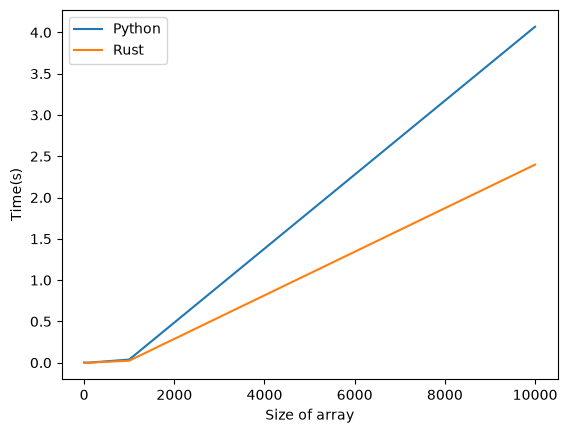

In [4]:
import matplotlib.pyplot as plt

plt.plot(sizeofarray, timings)
plt.xlabel("Size of array")
plt.ylabel("Time(s)")
plt.legend(["Python", "Rust"])
plt.show()

# Part 2: Patch Predictions As Annotations



### Patch predictions as annotations written fully in python



In [5]:
import numpy as np
from shapely.geometry import Polygon
from tqdm.auto import tqdm

from tiatoolbox.annotation.storage import Annotation


def py_patch_predictions_as_annotations(
    preds: list | np.ndarray,
    keys: list,
    class_dict: dict,
    class_probs: list | np.ndarray,
    patch_coords: list | np.ndarray,
    classes_predicted: list,
    labels: list,
    *,
    verbose: bool = True,
) -> list:
    """Helper function to generate annotation per patch predictions."""
    annotations = []
    tqdm_loop = tqdm(
        patch_coords,
        leave=False,
        desc="Converting outputs to AnnotationStore.",
        disable=not verbose,
    )

    for i, _ in enumerate(tqdm_loop):
        if "probabilities" in keys:
            props = {
                f"prob_{class_dict[j]}": class_probs[i][j] for j in classes_predicted
            }
        else:
            props = {}
        if "labels" in keys:
            props["label"] = class_dict[labels[i]]
        if len(preds) > 0:
            props["type"] = class_dict[preds[i]]
        annotations.append(Annotation(Polygon.from_bounds(*patch_coords[i]), props))

    return annotations

### Patch Predictions As Annotations with some code written in rust



In [6]:
def rust_patch_predictions_as_annotations(
    preds: list | np.ndarray,
    keys: list,
    class_dict: dict,
    class_probs: list | np.ndarray,
    patch_coords: list | np.ndarray,
    classes_predicted: list,
    labels: list,
) -> list:
    """Helper function to generate annotation per patch predictions."""
    if len(class_probs) == 0:
        class_probs = np.empty((0, 2))
    if len(patch_coords) == 0:
        patch_coords = np.empty((0, 2))
    return rmisc.patch_predictions_as_annotations(
        Annotation,
        Polygon,
        preds,
        "labels" in keys,
        "probabilities" in keys,
        class_dict,
        np.array(class_probs).astype("float"),
        np.array(patch_coords).astype("float"),
        classes_predicted,
        labels,
    )

## Comparison of speed it takes to run code in rust vs python



In [8]:
import time

sizeofarray = []
timings = []
timings = []
num_patches = 1
num_classes = 1
max_patches = 1000
while num_patches <= max_patches:
    python_times = np.empty(0)
    rust_times = np.empty(0)
    for _j in range(10):
        rng = np.random.default_rng(42)
        class_probs = rng.random(
            (num_patches, num_classes),
            dtype=np.float64,
        )
        class_probs /= class_probs.sum(axis=1, keepdims=True)
        preds = np.argmax(class_probs, axis=1).astype(np.float64).tolist()
        labels = (
            rng.integers(0, num_classes, size=num_patches).astype(np.int32).tolist()
        )
        x = np.arange(num_patches, dtype=np.float64) * 10
        y = np.zeros(num_patches, dtype=np.float64)
        patch_coords = np.column_stack((x, y, x + 10, y + 10))
        keys = ["predictions", "probabilities", "labels"]
        class_dict = {index: f"class_{index}" for index in range(num_classes)}
        classes_predicted = list(range(num_classes))
        verbose: bool = False
        start_time = time.time()
        python_object = py_patch_predictions_as_annotations(
            preds,
            keys,
            class_dict,
            class_probs,
            patch_coords,
            classes_predicted,
            labels,
            verbose=False,
        )
        python_end_time = time.time() - start_time
        python_times = np.append(python_times, python_end_time)
        start_time = time.time()
        rust_object = rust_patch_predictions_as_annotations(
            preds,
            keys,
            class_dict,
            class_probs,
            patch_coords,
            classes_predicted,
            labels,
        )
        rust_end_time = time.time() - start_time
        rust_times = np.append(rust_times, rust_end_time)
    sizeofarray.append(num_patches)
    timings.append([np.average(python_times), np.average(rust_times)])
    num_patches *= 10
    num_classes *= 10

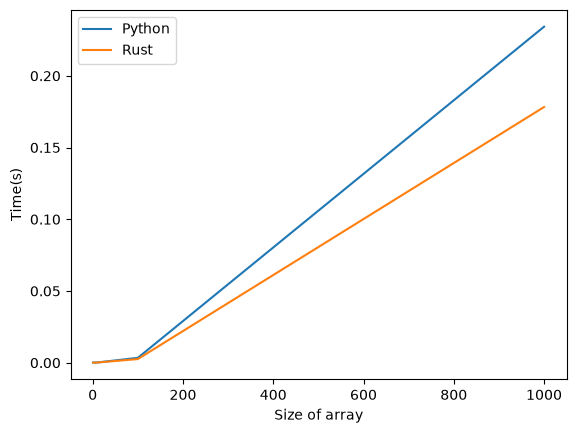

In [9]:
import matplotlib.pyplot as plt

plt.plot(sizeofarray, timings)
plt.xlabel("Size of array")
plt.ylabel("Time(s)")
plt.legend(["Python", "Rust"])
plt.show()

# Part 3: Patch Predictions As QuPath



### Patch predictions as qupath written fully in python



In [10]:
import numpy as np
from shapely.geometry import mapping


def py_patch_predictions_as_qupath_json(
    preds: list | np.ndarray,
    class_dict: dict,
    patch_coords: list | np.ndarray,
    *,
    verbose: bool = True,
) -> dict:
    """Helper function to generate QuPath JSON per patch predictions."""
    features = []
    # pick a color for each class based on the class index, using a colormap
    num_classes = len(class_dict)
    cmap = plt.colormaps["tab20"].resampled(num_classes)
    class_colours = {
        class_idx: [
            int(cmap(class_idx)[0] * 255),
            int(cmap(class_idx)[1] * 255),
            int(cmap(class_idx)[2] * 255),
        ]
        for class_idx in class_dict
    }

    tqdm_loop = tqdm(
        range(np.asarray(patch_coords).shape[0]),
        leave=False,
        desc="Converting outputs to QuPath JSON.",
        disable=not verbose,
    )

    for i in tqdm_loop:
        class_idx = int(preds[i])
        class_name = class_dict[class_idx]
        polygon_geo = Polygon.from_bounds(*patch_coords[i])
        polygon_feat = mapping(polygon_geo)

        feature = {
            "type": "Feature",
            "id": f"patch_{i}",
            "geometry": polygon_feat,
            "properties": {
                "classification": {
                    "name": class_name,
                    "color": class_colours[class_idx],
                }
            },
            "objectType": "annotation",
            "name": class_name,
            "class_value": class_idx,
        }

        features.append(feature)

    return {"type": "FeatureCollection", "features": features}

### Patch Predictions As QuPath Json with some code written in rust



In [11]:
def rust_patch_predictions_as_qupath_json(
    preds: list | np.ndarray,
    class_dict: dict,
    patch_coords: list | np.ndarray,
) -> dict:
    """Helper function to generate QuPath JSON per patch predictions."""
    num_classes = len(class_dict)
    cmap = plt.colormaps["tab20"].resampled(num_classes)
    class_colours = {
        class_idx: [
            int(cmap(class_idx)[0] * 255),
            int(cmap(class_idx)[1] * 255),
            int(cmap(class_idx)[2] * 255),
        ]
        for class_idx in class_dict
    }

    features = rmisc.patch_predictions_as_qupath_json(
        class_colours, preds, class_dict, np.array(patch_coords).astype("float")
    )
    return {"type": "FeatureCollection", "features": features}

## Comparison of speed it takes to run code in rust vs python



In [13]:
import time

import matplotlib.pyplot as plt

sizeofarray = []
timings = []
timings = []
num_patches = 1
num_classes = 1
max_patches = 1000
while num_patches <= max_patches:
    python_times = np.empty(0)
    rust_times = np.empty(0)
    for _j in range(10):
        rng = np.random.default_rng(42)
        class_probs = rng.random(
            (num_patches, num_classes),
            dtype=np.float64,
        )
        class_probs /= class_probs.sum(axis=1, keepdims=True)
        preds = np.argmax(class_probs, axis=1).astype(np.float64).tolist()
        x = np.arange(num_patches, dtype=np.float64) * 10
        y = np.zeros(num_patches, dtype=np.float64)
        patch_coords = np.column_stack((x, y, x + 10, y + 10))
        class_dict = {index: f"class_{index}" for index in range(num_classes)}
        classes_predicted = list(range(num_classes))
        verbose: bool = False
        start_time = time.time()
        python_object = py_patch_predictions_as_qupath_json(
            preds,
            class_dict,
            patch_coords,
            verbose=False,
        )
        python_end_time = time.time() - start_time
        python_times = np.append(python_times, python_end_time)
        start_time = time.time()
        rust_object = rust_patch_predictions_as_qupath_json(
            preds, class_dict, patch_coords
        )
        rust_end_time = time.time() - start_time
        rust_times = np.append(rust_times, rust_end_time)
    sizeofarray.append(num_patches)
    timings.append([np.average(python_times), np.average(rust_times)])
    num_patches *= 10
    num_classes *= 10

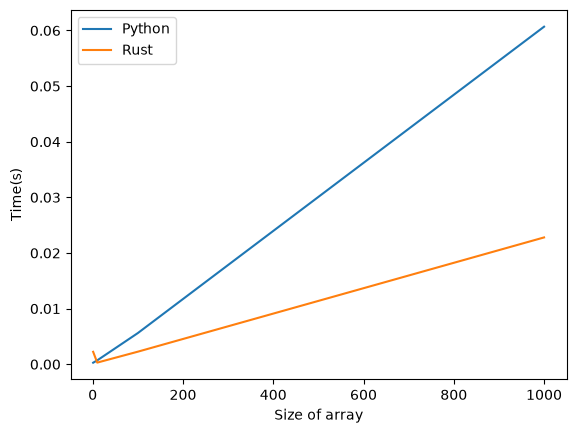

In [14]:
import matplotlib.pyplot as plt

plt.plot(sizeofarray, timings)
plt.xlabel("Size of array")
plt.ylabel("Time(s)")
plt.legend(["Python", "Rust"])
plt.show()

# Part 4: Json.dump



In [15]:
import json
import time
from pathlib import Path

import numpy as np

example_dict = {}
sizeofarray = []
timings = []
i = 10
maxarraysize = 10000
with Path.open("example.txt", "w") as handle:  # skipcq: PTC-W6004
    json.dump({"a": 1}, handle)
while i <= maxarraysize:
    python_times = np.empty(0)
    rust_times = np.empty(0)
    for j in range(len(example_dict), i):
        example_dict[str(j)] = 1
    for _j in range(10):
        start_time = time.time()
        with Path.open("example.txt", "w") as handle:  # skipcq: PTC-W6004
            json.dump(example_dict, handle)
        python_end_time = time.time() - start_time
        python_times = np.append(python_times, python_end_time)
        start_time = time.time()
        rmisc.json_dump_python_object("example.txt", example_dict)
        rust_end_time = time.time() - start_time
        rust_times = np.append(rust_times, rust_end_time)
    sizeofarray.append(len(example_dict))
    timings.append([np.average(python_times), np.average(rust_times)])
    i *= 10

[10, 100, 1000, 10000]
[[np.float64(0.0008447170257568359), np.float64(0.0008098840713500977)], [np.float64(0.0008617401123046875), np.float64(0.0008214950561523437)], [np.float64(0.002380967140197754), np.float64(0.0024411678314208984)], [np.float64(0.007615566253662109), np.float64(0.006029939651489258)]]


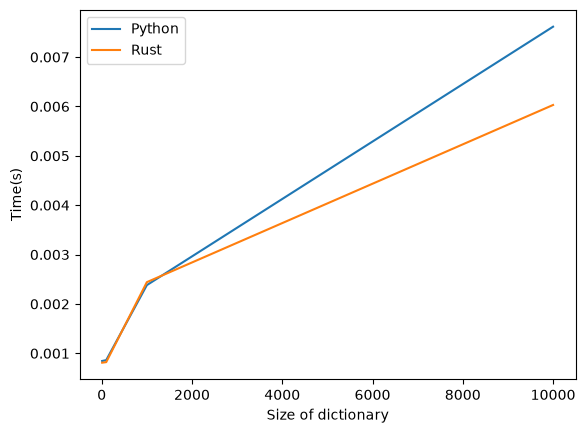

In [16]:
import matplotlib.pyplot as plt

plt.plot(sizeofarray, timings)
print(sizeofarray)
print(timings)
plt.xlabel("Size of dictionary")
plt.ylabel("Time(s)")
plt.legend(["Python", "Rust"])
plt.show()

# Part 5: String To Tuple



In [17]:
def py_string_to_tuple(in_str: str) -> tuple[str, ...]:
    """Splits input string to tuple at ','.

    Args:
        in_str (str):
            input string.

    Returns:
        tuple[str, ...]:
            Return a tuple of strings by splitting in_str at ','.

    """
    return tuple(substring.strip() for substring in in_str.split(","))

In [18]:
from tiatoolbox import rmisc


def rust_string_to_tuple(in_str: str) -> tuple[str, ...]:
    """Splits input string to tuple at ','.

    Args:
        in_str (str):
            input string.

    Returns:
        tuple[str, ...]:
            Return a tuple of strings by splitting in_str at ','.

    """
    return rmisc.string_to_tuple(in_str)

In [19]:
import time

import numpy as np

sizeofarray = []
timings = []
timings = []
i = 1
in_str = ""
max_patches = 100000
while i <= max_patches:
    python_times = np.empty(0)
    rust_times = np.empty(0)
    for j in range(int(len(in_str) / 2), i):
        in_str += " , " + str(j)
    for _j in range(10):
        start_time = time.time()
        python_object = py_string_to_tuple(in_str)
        python_end_time = time.time() - start_time
        python_times = np.append(python_times, python_end_time)
        start_time = time.time()
        rust_object = rust_string_to_tuple(in_str)
        rust_end_time = time.time() - start_time
        rust_times = np.append(rust_times, rust_end_time)
    sizeofarray.append(len(in_str))
    timings.append([np.average(python_times), np.average(rust_times)])
    i *= 10

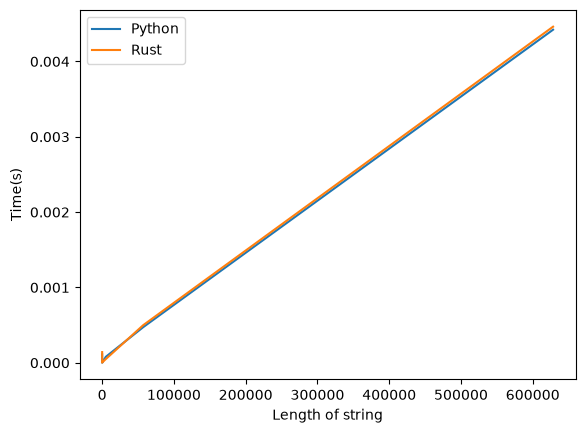

In [20]:
import matplotlib.pyplot as plt

plt.plot(sizeofarray, timings)
plt.xlabel("Length of string")
plt.ylabel("Time(s)")
plt.legend(["Python", "Rust"])
plt.show()

# Part 6: Semantic Segmentations As QuPath Json



In [21]:
from shapely.affinity import translate
from shapely.geometry.base import BaseGeometry


def make_valid_poly(
    poly: BaseGeometry,
    origin: tuple[float, float] | None = None,
) -> BaseGeometry:
    """Helper function to make a valid polygon.

    Args:
        poly (Polygon):
            The polygon to make valid.
        origin (Tuple[float, float]):
            The x and y coordinates to use as the origin for the annotation.

    Returns:
        geometry:
            A valid geometry.

    """
    if origin != (0, 0) and origin is not None:
        # transform coords to be relative to given pt.
        poly = translate(poly, -origin[0], -origin[1])
    if poly.is_valid:
        return poly
    logger.warning("Invalid geometry found, fix using buffer().", stacklevel=3)
    return poly.buffer(0.01)

In [22]:
def save_qupath_json(save_path: Path, qupath_json: dict) -> Path:
    """Saves QuPath JSON to disk."""
    save_path = save_path.with_suffix(".json")
    with Path.open(save_path, "w") as f:
        json.dump(qupath_json, f, indent=2)
    return save_path

In [23]:
def poly_geo_func(coords: list) -> list:
    """Used solely for function semantic_segmentation_as_qupath_json."""
    geom = make_valid_poly(
        feature2geometry(
            {
                "type": "Polygon",
                "coordinates": coords,
            }
        ),
        (0, 0),
    )
    return mapping(geom)

In [24]:
from pathlib import Path

import dask.array as da


def py_semantic_segmentations_as_qupath_json(
    layer_list: list,
    preds: da.Array,
    scale_factor: tuple[float, float],
    class_dict: dict,
    save_path: Path | None = None,
    *,
    verbose: bool = True,
) -> dict | Path:
    """Helper function to save semantic segmentation as QuPath json."""
    features: list = []

    # color map for classes
    num_classes = len(class_dict)
    cmap = plt.colormaps["tab20"].resampled(num_classes)
    class_colours = {
        class_idx: [
            int(cmap(class_idx)[0] * 255),
            int(cmap(class_idx)[1] * 255),
            int(cmap(class_idx)[2] * 255),
        ]
        for class_idx in class_dict
    }

    tqdm_loop = tqdm(
        layer_list,
        leave=False,
        desc="Converting outputs to QuPath JSON.",
        disable=not verbose,
    )

    for type_class in tqdm_loop:
        class_id = int(type_class)
        class_label = class_dict[class_id]

        # binary mask for this class
        layer = da.where(preds == type_class, 1, 0).astype("uint8").compute()

        contours, _ = cv2.findContours(layer, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_NONE)

        contours = cast("list[np.ndarray]", contours)

        # Convert contours to polygons
        for cnt in contours:
            if cnt.shape[0] < 3:  # noqa: PLR2004
                continue

            # scale coordinates
            cnt_scaled: np.ndarray = cnt.squeeze(1).astype(float)

            geom = make_valid_poly(
                feature2geometry(
                    {
                        "type": "Polygon",
                        "coordinates": scale_factor * np.array([cnt_scaled]),
                    }
                ),
                (0, 0),
            )
            poly_geo = mapping(geom)

            feature = {
                "type": "Feature",
                "geometry": poly_geo,
                "id": f"class_{class_id}_{len(features)}",
                "properties": {
                    "classification": {
                        "name": class_label,
                        "color": class_colours[class_id],
                    }
                },
                "objectType": "annotation",
                "name": class_label,
                "class_value": class_id,
            }

            features.append(feature)

    qupath_json = {"type": "FeatureCollection", "features": features}

    # if a save directory is provided, then dump JSON into a file
    if save_path:
        return save_qupath_json(save_path=save_path, qupath_json=qupath_json)

    return qupath_json

In [25]:
def rust_semantic_segmentations_as_qupath_json(
    layer_list: list,
    preds: da.Array,
    scale_factor: tuple[float, float],
    class_dict: dict,
    save_path: Path | None = None,
) -> dict | Path:
    """Helper function to save semantic segmentation as QuPath json."""
    num_classes = len(class_dict)
    cmap = plt.colormaps["tab20"].resampled(num_classes)
    class_colours = {
        class_idx: [
            int(cmap(class_idx)[0] * 255),
            int(cmap(class_idx)[1] * 255),
            int(cmap(class_idx)[2] * 255),
        ]
        for class_idx in class_dict
    }

    features = rmisc.semantic_segmentations_as_qupath_json(
        layer_list, preds, scale_factor, class_dict, class_colours, cv2, poly_geo_func
    )

    qupath_json = {"type": "FeatureCollection", "features": features}

    # if a save directory is provided, then dump JSON into a file
    if save_path:
        return save_qupath_json(save_path=save_path, qupath_json=qupath_json)

    return qupath_json

In [26]:
import time
from typing import cast

import cv2
import dask.array as da
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import shape as feature2geometry

from tiatoolbox import logger, rmisc

sizeofarray = []
timings = []
timings = []
num_patches = 10
num_classes = 10
max_patches = 1000
while num_patches <= max_patches:
    python_times = np.empty(0)
    rust_times = np.empty(0)
    for _j in range(10):
        rng = np.random.default_rng(42)

        # Exclude background
        layer_list = list(range(1, num_classes))

        # Make the image reasonably large compared with number of patches
        height = 64
        width = 64

        # Start entirely as background
        preds_np = np.zeros((height, width), dtype=np.int32)

        for _ in range(num_patches):
            class_id = int(rng.integers(1, num_classes))

            # Rectangle dimensions, at least 3x3
            rect_h = int(rng.integers(3, 10))
            rect_w = int(rng.integers(3, 10))

            y = int(rng.integers(1, height - rect_h - 1))
            x = int(rng.integers(1, width - rect_w - 1))

            # Only place the rectangle if the surrounding region is empty.
            # The extra 1-pixel margin prevents polygons from touching.
            region = preds_np[
                y - 1 : y + rect_h + 1,
                x - 1 : x + rect_w + 1,
            ]

            if np.all(region == 0):
                preds_np[
                    y : y + rect_h,
                    x : x + rect_w,
                ] = class_id

        preds = da.from_array(
            preds_np,
            chunks=(32, 32),
        )

        scale_factor = (0.5, 0.5)

        class_dict = {
            0: "background",
            **{class_id: f"class_{class_id}" for class_id in range(1, num_classes)},
        }
        start_time = time.time()
        python_object = py_semantic_segmentations_as_qupath_json(
            layer_list, preds, scale_factor, class_dict, None
        )
        python_end_time = time.time() - start_time
        python_times = np.append(python_times, python_end_time)
        start_time = time.time()
        rust_object = rust_semantic_segmentations_as_qupath_json(
            layer_list, preds, scale_factor, class_dict, None
        )
        rust_end_time = time.time() - start_time
        rust_times = np.append(rust_times, rust_end_time)
    sizeofarray.append(num_patches)
    timings.append([np.average(python_times), np.average(rust_times)])
    num_patches *= 10
    num_classes *= 10

Converting outputs to QuPath JSON.:   0%|          | 0/9 [00:00<?, ?it/s]

Converting outputs to QuPath JSON.:   0%|          | 0/9 [00:00<?, ?it/s]

Converting outputs to QuPath JSON.:   0%|          | 0/9 [00:00<?, ?it/s]

Converting outputs to QuPath JSON.:   0%|          | 0/9 [00:00<?, ?it/s]

Converting outputs to QuPath JSON.:   0%|          | 0/9 [00:00<?, ?it/s]

...

Converting outputs to QuPath JSON.:   0%|          | 0/999 [00:00<?, ?it/s]

Converting outputs to QuPath JSON.:   0%|          | 0/999 [00:00<?, ?it/s]

Converting outputs to QuPath JSON.:   0%|          | 0/999 [00:00<?, ?it/s]

Converting outputs to QuPath JSON.:   0%|          | 0/999 [00:00<?, ?it/s]

Converting outputs to QuPath JSON.:   0%|          | 0/999 [00:00<?, ?it/s]

[[np.float64(0.03665416240692139), np.float64(0.03360826969146728)], [np.float64(0.3465502977371216), np.float64(0.30228404998779296)], [np.float64(3.503210759162903), np.float64(2.9717938184738157)]]


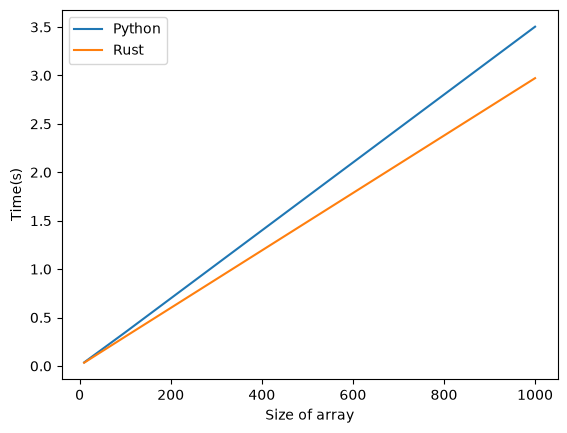

In [27]:
import matplotlib.pyplot as plt

print(timings)
plt.plot(sizeofarray, timings)
plt.xlabel("Size of array")
plt.ylabel("Time(s)")
plt.legend(["Python", "Rust"])
plt.show()